**Author**: Martin Gamboa 

**Github**: mmgamboa

**Date**: January 10th, 2025

# Problem

What does high correlation of returns imply for long-term behavior of two assets prices? Analyze some examples to support your answer. You can get price data from yahoo finance.


In [ ]:
# Load basic packages
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

# Load specific packages
import yfinance as yf

# Load mymodule
import sys
sys.path.append('..')
from src.features.build_features import compute_daily_return


## Explanation
_Get data_

* Get the data from external source using Yahoo Finance,

_Trends_

* Define Return computation for individual data and dataset. We will use log return for continuous compounding and 'Adj Close' column. This election is because we account for stock, dividends, and other corporate actions, providing a more accurate representation of the stock's performance over time,

* We plot using `plotly` and with dynamic box showing simultaneously the return for all the companies considered for this analysis. I did it twice: one step-by-step developing my own functions and another using built-in methods from `Pandas` (see _Same using built-in methods_ sub-section).

# Get data

In [17]:
# Download data for the past year
# We use period="1y" and interval="1d" to get the data for the past year with daily frequency because we are 
# interested in long-term investment

companies_name = ["MELI",
                "MSFT", 
                "AAPL", 
                "HPQ"]  
             
#get_data = yf.download(companies_name, period="1y", interval="1d")
get_data = pd.read_csv('../data/raw/AAPL_HPQ_MELI_MSFT_20240202_20250201.csv',
                       header=[0, 1], index_col=0)   

In [18]:
get_data

Price        Adj Close                                           Close  \
Ticker            AAPL        HPQ         MELI        MSFT        AAPL   
Date                                                                     
2024-02-02  184.740845  27.743511  1772.900024  408.167755  185.850006   
2024-02-05  186.559906  27.404938  1774.750000  402.639130  187.679993   
2024-02-06  188.170242  27.366245  1710.390015  402.480286  189.300003   
2024-02-07  188.279602  27.037348  1713.869995  410.976715  189.410004   
2024-02-08  187.196106  27.366245  1732.829956  411.036316  188.320007   
...                ...        ...          ...         ...         ...   
2025-01-27  229.607544  33.330002  1846.000000  434.559998  229.860001   
2025-01-28  237.998322  32.740002  1895.530029  447.200012  238.259995   
2025-01-29  239.097122  32.610001  1889.760010  442.329987  239.360001   
2025-01-30  237.329056  32.799999  1947.319946  414.989990  237.589996   
2025-01-31  235.740814  32.500000  1922.189941  415.059998  236.000000   

Price                                                 High             ...  \
Ticker            HPQ         MELI        MSFT        AAPL        HPQ  ...   
Date                                                                   ...   
2024-02-02  28.680000  1772.900024  411.220001  187.330002  28.820000  ...   
2024-02-05  28.330000  1774.750000  405.649994  189.250000  28.590000  ...   
2024-02-06  28.290001  1710.390015  405.489990  189.309998  28.549999  ...   
2024-02-07  27.950001  1713.869995  414.049988  191.050003  28.250000  ...   
2024-02-08  28.290001  1732.829956  414.109985  189.539993  28.299999  ...   
...               ...          ...         ...         ...        ...  ...   
2025-01-27  33.330002  1846.000000  434.559998  232.149994  33.360001  ...   
2025-01-28  32.740002  1895.530029  447.200012  240.190002  33.200001  ...   
2025-01-29  32.610001  1889.760010  442.329987  239.860001  33.060001  ...   
2025-01-30  32.799999  1947.319946  414.989990  240.789993  33.080002  ...   
2025-01-31  32.500000  1922.189941  415.059998  247.190002  33.330002  ...   

Price               Low                    Open                          \
Ticker             MELI        MSFT        AAPL        HPQ         MELI   
Date                                                                      
2024-02-02  1726.319946  403.559998  179.860001  28.770000  1727.079956   
2024-02-05  1752.060059  403.989990  188.149994  28.570000  1769.819946   
2024-02-06  1676.010010  402.910004  186.860001  28.350000  1770.000000   
2024-02-07  1704.369995  407.399994  190.639999  28.250000  1718.449951   
2024-02-08  1712.650024  412.529999  189.389999  28.000000  1729.329956   
...                 ...         ...         ...        ...          ...   
2025-01-27  1787.260010  423.500000  224.020004  32.529999  1800.060059   
2025-01-28  1826.530029  431.380005  230.850006  33.189999  1847.589966   
2025-01-29  1869.430054  440.399994  234.119995  33.049999  1900.520020   
2025-01-30  1913.060059  413.160004  238.669998  33.020000  1921.729980   
2025-01-31  1918.959961  414.910004  247.190002  32.980000  1950.000000   

Price                      Volume                              
Ticker            MSFT       AAPL       HPQ    MELI      MSFT  
Date                                                           
2024-02-02  403.809998  102518000   7193000  304900  28245000  
2024-02-05  409.899994   69668800  10526200  200400  25352300  
2024-02-06  405.880005   43490800   7926000  704200  18382600  
2024-02-07  407.440002   53439000   7358000  442800  22340500  
2024-02-08  414.049988   40962000   4639200  297600  21225300  
...                ...        ...       ...     ...       ...  
2025-01-27  424.010010   94863400  10177000  355800  35647800  
2025-01-28  434.600006   75707600   5955800  351700  23491700  
2025-01-29  446.690002   45486100   4039400  181800  23581400  
2025-01-30  418.769989   55658300   3611700  486900

In [20]:
# Get date using .index
dates = get_data.index
#dates = [d.strftime('%Y-%m-%d') for d in dates]

Save data in file if needed (Pandas)

In [21]:
# Save to CSV (optional)
to_save = False
if to_save:
    save_data = get_data.copy()
    save_data.to_csv("stock_prices_last_year.csv")


# Trends

In [22]:
param_to_analyze = 'Adj Close'

returns_of_companies = compute_daily_return(get_data[param_to_analyze], dates, companies_name)

In [23]:
# Plot return for each company
fig = px.line(returns_of_companies, 
              x=returns_of_companies.index, 
              y=returns_of_companies.columns, 
              title='Daily return of companies')
# For each x-value show all the y-values simultaneously in the dynamic box
fig.update_traces(hoverinfo='y')
fig.update_layout(hovermode = "x unified")
# Change y-axis name
fig.update_yaxes(title_text="Return")
# Show the plot
fig.show()

### Same using built-in methods

In [24]:
# Compute pct_change for all the companies simultaneously
for ilabel in companies_name:
    get_data[(param_to_analyze, ilabel + ' Daily Return')] = get_data[(param_to_analyze, ilabel)].pct_change()
    # Alternatively, calculate log returns
    get_data[(param_to_analyze, ilabel + ' Log Return')] = np.log(get_data[(param_to_analyze, ilabel)] / get_data[(param_to_analyze, ilabel)].shift(1))

print(get_data[(param_to_analyze, 'AAPL Log Return')])
# Plot the daily return
fig = px.line(get_data, x=get_data.index, 
              y=[get_data[(param_to_analyze, ilabel + ' Log Return')].values for ilabel in companies_name], 
              title='Log return of companies')
fig.update_traces(hoverinfo='y')
fig.update_layout(hovermode = "x unified")
fig.update_yaxes(title_text="Return")
fig.show()

Date
2024-02-02         NaN
2024-02-05    0.009798
2024-02-06    0.008595
2024-02-07    0.000581
2024-02-08   -0.005771
                ...   
2025-01-27    0.031286
2025-01-28    0.035892
2025-01-29    0.004606
2025-01-30   -0.007422
2025-01-31   -0.006715
Name: (Adj Close, AAPL Log Return), Length: 250, dtype: float64


# Correlation computation

          MELI      MSFT      AAPL       HPQ
MELI  1.000000  0.147427  0.153573  0.085365
MSFT  0.147427  1.000000  0.445329  0.150775
AAPL  0.153573  0.445329  1.000000  0.197920
HPQ   0.085365  0.150775  0.197920  1.000000


<Axes: >

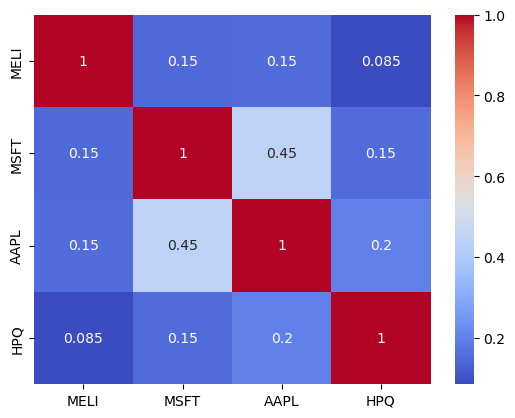

In [25]:
# Compute the correlation matrix
correlation = returns_of_companies.corr()
print(correlation)
# Plot the correlation matrix
sns.heatmap(correlation, annot=True, cmap='coolwarm')



# Correlation by hand

Example of how to apply step by step a correlation betwen two variables.

In [26]:
x = returns_of_companies['HPQ'].values
y = returns_of_companies['AAPL'].values

mean_x = np.mean(x)
mean_y = np.mean(y)

den_x = np.sqrt(np.sum((x - mean_x)**2))
den_y = np.sqrt(np.sum((y - mean_y)**2))

r_xy= np.sum((x - mean_x) * (y - mean_y)) / (den_x * den_y)

print(f"Pearson correlation coefficient between HPQ and Apple: {r_xy:3.2f}")

Pearson correlation coefficient between HPQ and Apple: 0.20
